In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML — LightGBM regressor (for LGD model)
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilities
import os
import gc
import joblib
import warnings
warnings.filterwarnings('ignore')

# Display
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/Data/credit-risk-modeling'
DATA_FILE = f'{DRIVE_PATH}/accepted_2007_to_2018Q4.csv.gz'

print("✓ All libraries imported")

✓ All libraries imported


In [3]:
%%time
# Columns we need for LGD modeling
columns_needed = [
    # Identifiers + status
    'id', 'loan_status', 'issue_d',

    # Loan terms
    'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade',

    # Recovery info (the key columns!)
    'total_pymnt', 'total_rec_prncp', 'total_rec_int',
    'recoveries', 'collection_recovery_fee', 'out_prncp',

    # Borrower features for LGD model
    'annual_inc', 'dti', 'fico_range_low', 'fico_range_high',
    'home_ownership', 'verification_status', 'purpose',
    'emp_length', 'addr_state', 'application_type',
]

# Load only needed columns
df_raw = pd.read_csv(DATA_FILE,
                     compression='gzip',
                     usecols=columns_needed,
                     low_memory=False)

print(f"\nLoaded raw data: {df_raw.shape}")
print(f"Memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Filter to defaulted loans only (same definition as PD phase: Basel 90+ DPD)
default_statuses = ['Charged Off', 'Default', 'Late (31-120 days)']
df_default = df_raw[df_raw['loan_status'].isin(default_statuses)].copy()

del df_raw
gc.collect()

print(f"\nDefaulted loans: {len(df_default):,}")
print(f"\nDefault status distribution:")
print(df_default['loan_status'].value_counts())


Loaded raw data: (2260701, 25)
Memory: 1684.1 MB

Defaulted loans: 290,066

Default status distribution:
loan_status
Charged Off           268559
Late (31-120 days)     21467
Default                   40
Name: count, dtype: int64
CPU times: user 32 s, sys: 12.4 s, total: 44.4 s
Wall time: 52.3 s


In [4]:
# Calculate net recovery
df_default['net_recovery'] = (
    df_default['total_rec_prncp']
    + df_default['recoveries']
    - df_default['collection_recovery_fee']
)

# Calculate loss
df_default['loss_amount'] = df_default['funded_amnt'] - df_default['net_recovery']

# Calculate LGD (bounded to [0, 1])
df_default['lgd'] = df_default['loss_amount'] / df_default['funded_amnt']
df_default['lgd'] = df_default['lgd'].clip(lower=0, upper=1)

# Recovery rate = 1 - LGD
df_default['recovery_rate'] = 1 - df_default['lgd']

# Summary statistics
print("LGD Statistics:\n")
print(df_default[['funded_amnt', 'net_recovery', 'loss_amount',
                  'lgd', 'recovery_rate']].describe().round(4))

print(f"\nLGD percentiles:")
for p in [10, 25, 50, 75, 90, 95]:
    val = df_default['lgd'].quantile(p/100)
    print(f"  {p}th percentile: {val:.4f}")

LGD Statistics:

       funded_amnt  net_recovery  loss_amount         lgd  recovery_rate
count  290066.0000   290066.0000  290066.0000 290066.0000    290066.0000
mean    15659.7306     5408.5296   10251.2010      0.6354         0.3646
std      8884.7341     4491.9199    7315.5613      0.2171         0.2171
min       900.0000        0.0000  -12639.2400      0.0000         0.0000
25%      9000.0000     2253.9400    4484.9096      0.4963         0.1957
50%     14400.0000     4190.9428    8656.3604      0.6777         0.3223
75%     20800.0000     7212.3700   14326.8580      0.8043         0.5037
max     40000.0000    42744.0156   40000.0000      1.0000         1.0000

LGD percentiles:
  10th percentile: 0.3138
  25th percentile: 0.4963
  50th percentile: 0.6777
  75th percentile: 0.8043
  90th percentile: 0.8827
  95th percentile: 0.9259


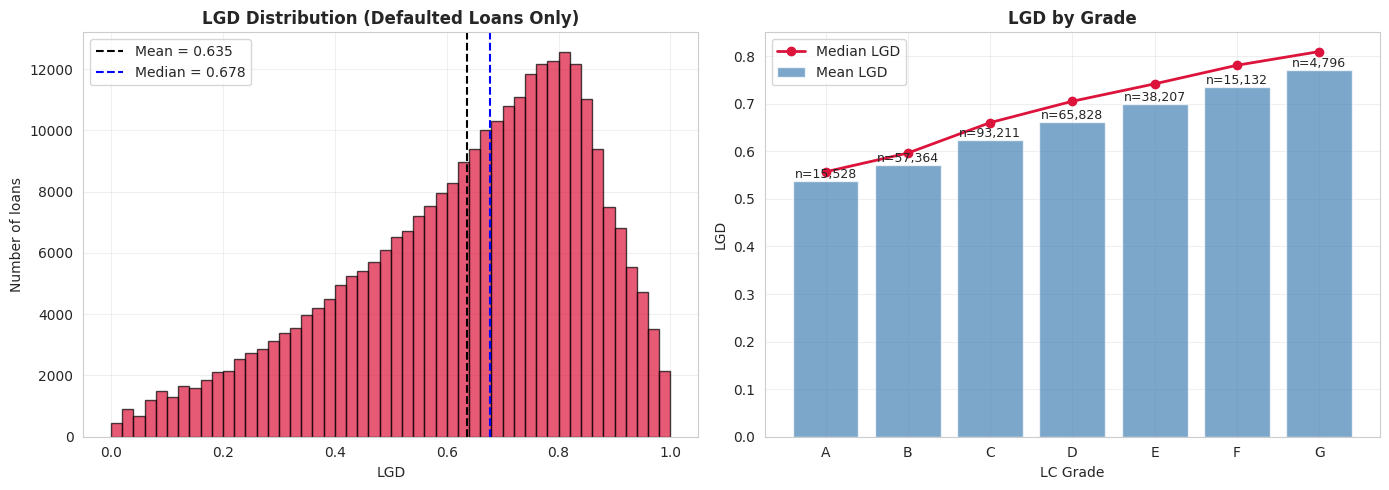


LGD by Grade:
grade   mean  median  count
    A 0.5380  0.5569  15528
    B 0.5711  0.5963  57364
    C 0.6234  0.6602  93211
    D 0.6619  0.7052  65828
    E 0.6991  0.7417  38207
    F 0.7346  0.7808  15132
    G 0.7706  0.8096   4796


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of LGD
ax = axes[0]
ax.hist(df_default['lgd'], bins=50, color='crimson', alpha=0.7, edgecolor='black')
ax.axvline(df_default['lgd'].mean(), color='black', linestyle='--',
           label=f'Mean = {df_default["lgd"].mean():.3f}')
ax.axvline(df_default['lgd'].median(), color='blue', linestyle='--',
           label=f'Median = {df_default["lgd"].median():.3f}')
ax.set_xlabel('LGD')
ax.set_ylabel('Number of loans')
ax.set_title('LGD Distribution (Defaulted Loans Only)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Recovery rate by grade
ax = axes[1]
lgd_by_grade = df_default.groupby('grade')['lgd'].agg(['mean', 'median', 'count']).reset_index()
lgd_by_grade = lgd_by_grade.sort_values('grade')

ax.bar(lgd_by_grade['grade'], lgd_by_grade['mean'],
       color='steelblue', alpha=0.7, label='Mean LGD')
ax.plot(lgd_by_grade['grade'], lgd_by_grade['median'],
        'o-', color='crimson', label='Median LGD', linewidth=2)
ax.set_xlabel('LC Grade')
ax.set_ylabel('LGD')
ax.set_title('LGD by Grade', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Annotate count
for i, row in lgd_by_grade.iterrows():
    ax.annotate(f'n={row["count"]:,}',
                xy=(row['grade'], row['mean']),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nLGD by Grade:")
print(lgd_by_grade.to_string(index=False))

In [6]:
# Convert term: " 36 months" → 36
df_default['term'] = df_default['term'].str.extract(r'(\d+)').astype(int)

# Convert emp_length: "10+ years" → 10, etc.
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10,
}
df_default['emp_length'] = df_default['emp_length'].map(emp_length_map)

# Ordinal encoding for grade
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_default['grade'] = df_default['grade'].map(grade_map)

# FICO average
df_default['fico_avg'] = (df_default['fico_range_low'] + df_default['fico_range_high']) / 2

# Issue year (for time tracking, not as feature)
df_default['issue_d'] = pd.to_datetime(df_default['issue_d'], format='%b-%Y', errors='coerce')
df_default['issue_year'] = df_default['issue_d'].dt.year

# Loan to income ratio
df_default['loan_to_income'] = df_default['funded_amnt'] / (df_default['annual_inc'] + 1)
df_default['loan_to_income'] = df_default['loan_to_income'].clip(upper=0.5)  # Same cap as PD phase

# Drop rows with missing critical values
critical_cols = ['term', 'fico_avg', 'annual_inc', 'dti', 'grade']
df_default_clean = df_default.dropna(subset=critical_cols).copy()

print(f"Defaulted loans: {len(df_default):,}")
print(f"After dropping NaN in critical features: {len(df_default_clean):,}")
print(f"Dropped: {len(df_default) - len(df_default_clean):,} rows")

Defaulted loans: 290,066
After dropping NaN in critical features: 289,971
Dropped: 95 rows


In [7]:
# Select features for LGD model
numeric_features = [
    'funded_amnt', 'int_rate', 'term', 'installment',
    'annual_inc', 'dti', 'fico_avg', 'emp_length',
    'grade', 'loan_to_income',
]

categorical_features = [
    'home_ownership', 'verification_status', 'purpose', 'application_type',
]

# Impute missing values
for col in numeric_features:
    if df_default_clean[col].isnull().any():
        median_val = df_default_clean[col].median()
        df_default_clean[col] = df_default_clean[col].fillna(median_val)

for col in categorical_features:
    if df_default_clean[col].isnull().any():
        mode_val = df_default_clean[col].mode().iloc[0]
        df_default_clean[col] = df_default_clean[col].fillna(mode_val)

# One-hot encode categoricals
df_features = pd.get_dummies(
    df_default_clean[numeric_features + categorical_features],
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

# Target = LGD
y_lgd = df_default_clean['lgd'].values

print(f"LGD modeling dataset:")
print(f"  Features shape: {df_features.shape}")
print(f"  Target shape:   {y_lgd.shape}")
print(f"  Target stats:   mean={y_lgd.mean():.4f}, std={y_lgd.std():.4f}")

LGD modeling dataset:
  Features shape: (289971, 31)
  Target shape:   (289971,)
  Target stats:   mean=0.6354, std=0.2171


In [8]:
%%time
# Random 80/20 split
X_lgd_train, X_lgd_test, y_lgd_train, y_lgd_test = train_test_split(
    df_features, y_lgd,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_lgd_train.shape}, mean LGD: {y_lgd_train.mean():.4f}")
print(f"Test:  {X_lgd_test.shape}, mean LGD: {y_lgd_test.mean():.4f}\n")

# Further split train into train + val for early stopping
X_lgd_tr, X_lgd_val, y_lgd_tr, y_lgd_val = train_test_split(
    X_lgd_train, y_lgd_train,
    test_size=0.1,
    random_state=RANDOM_STATE,
)

# Train LightGBM regressor
lgd_model = lgb.LGBMRegressor(
    objective='regression_l1',   # MAE (more robust than MSE for LGD)
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=100,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgd_model.fit(
    X_lgd_tr, y_lgd_tr,
    eval_set=[(X_lgd_val, y_lgd_val)],
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50),
    ],
)

print(f"\n✓ LGD model trained")
print(f"  Best iteration: {lgd_model.best_iteration_}")
print(f"  Best val MAE:   {lgd_model.best_score_['valid_0']['l1']:.4f}")

Train: (231976, 31), mean LGD: 0.6354
Test:  (57995, 31), mean LGD: 0.6354

Training until validation scores don't improve for 50 rounds
[50]	valid_0's l1: 0.157092
[100]	valid_0's l1: 0.15357
[150]	valid_0's l1: 0.151881
[200]	valid_0's l1: 0.150847
[250]	valid_0's l1: 0.150054
[300]	valid_0's l1: 0.149503
[350]	valid_0's l1: 0.148957
[400]	valid_0's l1: 0.148653
[450]	valid_0's l1: 0.148447
[500]	valid_0's l1: 0.148262
[550]	valid_0's l1: 0.148174
[600]	valid_0's l1: 0.148111
[650]	valid_0's l1: 0.148036
[700]	valid_0's l1: 0.14797
[750]	valid_0's l1: 0.147923
[800]	valid_0's l1: 0.147832
[850]	valid_0's l1: 0.147779
[900]	valid_0's l1: 0.147718
[950]	valid_0's l1: 0.147698
[1000]	valid_0's l1: 0.147681
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 0.147681

✓ LGD model trained
  Best iteration: 1000
  Best val MAE:   0.1477
CPU times: user 33.6 s, sys: 76.4 ms, total: 33.6 s
Wall time: 24.8 s


LGD Model Performance:

              Model    MAE   RMSE      R²
Baseline (mean LGD) 0.1769 0.2162 -0.0000
           LightGBM 0.1469 0.1902  0.2259

Improvement over baseline: MAE -17.0%


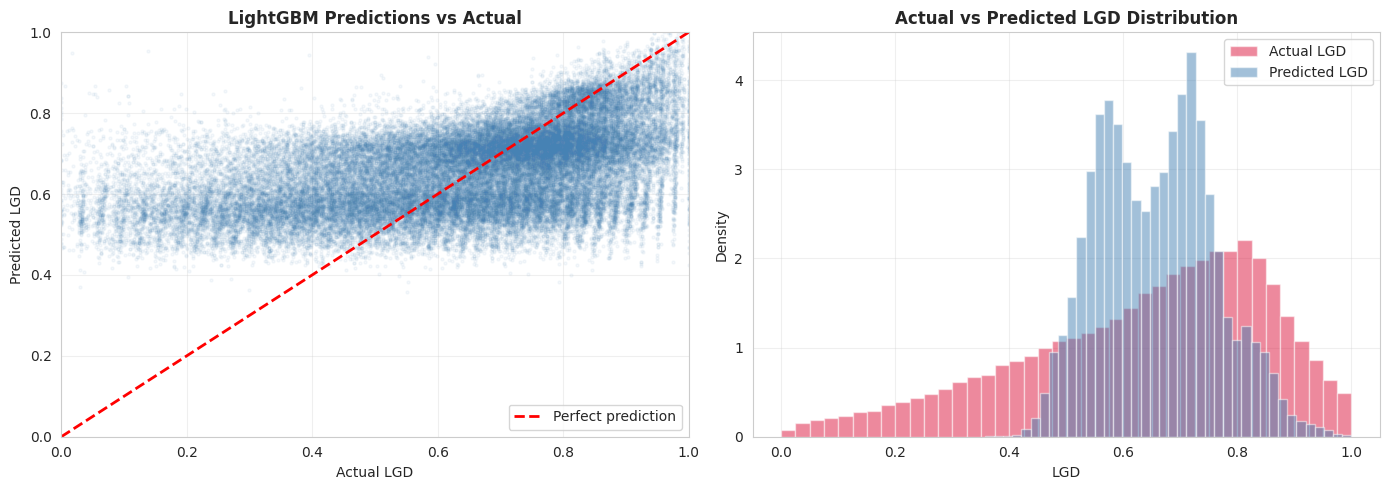

In [9]:
# Predict on test set (clip to [0, 1])
y_lgd_pred = lgd_model.predict(X_lgd_test)
y_lgd_pred = np.clip(y_lgd_pred, 0, 1)

# Baseline: predict mean LGD for all
baseline_pred = np.full_like(y_lgd_test, y_lgd_train.mean())

# Metrics
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': label, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

results = pd.DataFrame([
    evaluate(y_lgd_test, baseline_pred, 'Baseline (mean LGD)'),
    evaluate(y_lgd_test, y_lgd_pred, 'LightGBM'),
])

print("LGD Model Performance:\n")
print(results.round(4).to_string(index=False))
print(f"\nImprovement over baseline: "
      f"MAE -{(results['MAE'][0] - results['MAE'][1]) / results['MAE'][0] * 100:.1f}%")

# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(y_lgd_test, y_lgd_pred, alpha=0.05, s=5, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual LGD')
ax.set_ylabel('Predicted LGD')
ax.set_title('LightGBM Predictions vs Actual', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)

# Distribution comparison
ax = axes[1]
ax.hist(y_lgd_test, bins=40, alpha=0.5, label='Actual LGD', color='crimson', density=True)
ax.hist(y_lgd_pred, bins=40, alpha=0.5, label='Predicted LGD', color='steelblue', density=True)
ax.set_xlabel('LGD')
ax.set_ylabel('Density')
ax.set_title('Actual vs Predicted LGD Distribution', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

EAD Statistics (Test Portfolio — 240,864 loans):

  Mean EAD:    $ 14,604.71
  Median EAD:  $ 12,000.00
  Min EAD:     $  1,000.00
  Max EAD:     $ 40,000.00
  Total EAD:   $      3.52B (portfolio total)


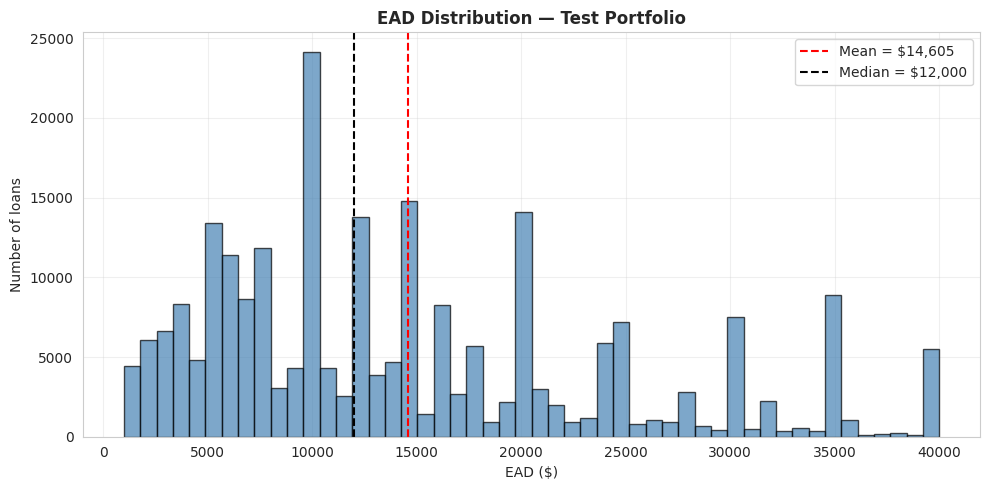

In [10]:
# Load PD test set (saved from Phase 3)
X_test_pd = pd.read_parquet(f'{DRIVE_PATH}/X_test.parquet')
y_test_pd = pd.read_parquet(f'{DRIVE_PATH}/y_test.parquet').squeeze('columns')

# EAD = funded_amnt (already in the dataset)
ead = X_test_pd['funded_amnt'].values

print(f"EAD Statistics (Test Portfolio — {len(ead):,} loans):\n")
print(f"  Mean EAD:    ${ead.mean():>10,.2f}")
print(f"  Median EAD:  ${np.median(ead):>10,.2f}")
print(f"  Min EAD:     ${ead.min():>10,.2f}")
print(f"  Max EAD:     ${ead.max():>10,.2f}")
print(f"  Total EAD:   ${ead.sum() / 1e9:>10,.2f}B (portfolio total)")

# Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ead, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(ead.mean(), color='red', linestyle='--', label=f'Mean = ${ead.mean():,.0f}')
ax.axvline(np.median(ead), color='black', linestyle='--', label=f'Median = ${np.median(ead):,.0f}')
ax.set_xlabel('EAD ($)')
ax.set_ylabel('Number of loans')
ax.set_title('EAD Distribution — Test Portfolio', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Load PD model artifacts from Phase 4
MODELS_DIR = f'{DRIVE_PATH}/models'
pd_model = joblib.load(f'{MODELS_DIR}/lgb_model.pkl')

print(f"✓ Loaded PD model (LightGBM): {pd_model}")

# Predict PD on test portfolio
pd_predictions = pd_model.predict_proba(X_test_pd)[:, 1]

print(f"\nPD predictions (test portfolio):")
print(f"  Mean PD:    {pd_predictions.mean():.4f}")
print(f"  Median PD:  {np.median(pd_predictions):.4f}")
print(f"  Min PD:     {pd_predictions.min():.4f}")
print(f"  Max PD:     {pd_predictions.max():.4f}")
print(f"\nActual bad rate (test): {y_test_pd.mean():.4f}")

✓ Loaded PD model (LightGBM): LGBMClassifier(learning_rate=0.03, min_child_samples=100, n_estimators=1000,
               n_jobs=-1, random_state=42, reg_alpha=0.1, reg_lambda=0.1,
               verbose=-1)

PD predictions (test portfolio):
  Mean PD:    0.2389
  Median PD:  0.2148
  Min PD:     0.0076
  Max PD:     0.8377

Actual bad rate (test): 0.2627


In [12]:
# Calculate mean LGD by grade from observed defaults
lgd_by_grade = df_default_clean.groupby('grade')['lgd'].mean().to_dict()

print("Mean observed LGD by grade (from defaulted loans):\n")
grade_letter_map = {1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G'}
for grade_num in sorted(lgd_by_grade.keys()):
    print(f"  Grade {grade_letter_map[grade_num]}: LGD = {lgd_by_grade[grade_num]:.4f}")

# Apply to test portfolio
test_grades = X_test_pd['grade'].values
lgd_predictions = np.array([lgd_by_grade[g] for g in test_grades])

print(f"\nLGD assigned to test portfolio:")
print(f"  Mean LGD:    {lgd_predictions.mean():.4f}")
print(f"  Median LGD:  {np.median(lgd_predictions):.4f}")

Mean observed LGD by grade (from defaulted loans):

  Grade A: LGD = 0.5380
  Grade B: LGD = 0.5711
  Grade C: LGD = 0.6234
  Grade D: LGD = 0.6618
  Grade E: LGD = 0.6991
  Grade F: LGD = 0.7346
  Grade G: LGD = 0.7706

LGD assigned to test portfolio:
  Mean LGD:    0.6089
  Median LGD:  0.6234


In [13]:
# Calculate ECL per loan
ecl_per_loan = pd_predictions * lgd_predictions * ead

# Combine into a portfolio DataFrame
portfolio = pd.DataFrame({
    'pd': pd_predictions,
    'lgd': lgd_predictions,
    'ead': ead,
    'ecl': ecl_per_loan,
    'grade': X_test_pd['grade'].values,
    'actual_default': y_test_pd.values,
    'actual_loss': y_test_pd.values * lgd_predictions * ead,  # actual default × LGD × EAD
})

print("ECL Statistics (per loan):")
print(portfolio[['pd', 'lgd', 'ead', 'ecl']].describe().round(2))

print(f"\nPortfolio-level totals:")
print(f"  Total exposure (EAD):  ${portfolio['ead'].sum() / 1e9:>10,.3f}B")
print(f"  Total predicted ECL:   ${portfolio['ecl'].sum() / 1e6:>10,.2f}M")
print(f"  Total actual losses:   ${portfolio['actual_loss'].sum() / 1e6:>10,.2f}M")
print(f"  ECL/EAD ratio:         {portfolio['ecl'].sum() / portfolio['ead'].sum() * 100:.2f}%")
print(f"  Actual loss/EAD ratio: {portfolio['actual_loss'].sum() / portfolio['ead'].sum() * 100:.2f}%")

ECL Statistics (per loan):
               pd         lgd         ead         ecl
count 240864.0000 240864.0000 240864.0000 240864.0000
mean       0.2400      0.6100  14604.7100   2428.4200
std        0.1500      0.0500   9678.9600   2638.7000
min        0.0100      0.5400   1000.0000      4.6000
25%        0.1200      0.5700   7000.0000    562.1700
50%        0.2100      0.6200  12000.0000   1453.1400
75%        0.3300      0.6200  20000.0000   3392.5000
max        0.8400      0.7700  40000.0000  23726.2300

Portfolio-level totals:
  Total exposure (EAD):  $     3.518B
  Total predicted ECL:   $    584.92M
  Total actual losses:   $    653.72M
  ECL/EAD ratio:         16.63%
  Actual loss/EAD ratio: 18.58%


Portfolio ECL by Grade:

Grade  N Loans  Avg PD  Avg LGD  Predicted ECL %  Actual Loss %
    A    40716  0.0674   0.5380           3.6873         5.2923
    B    65654  0.1622   0.5711           9.6494        12.0816
    C    75110  0.2694   0.6234          17.6017        20.1674
    D    37662  0.3635   0.6618          25.1617        26.9764
    E    14593  0.4441   0.6991          32.1950        32.2660
    F     4685  0.5161   0.7346          38.4524        37.7098
    G     2444  0.5420   0.7706          42.0447        41.5653


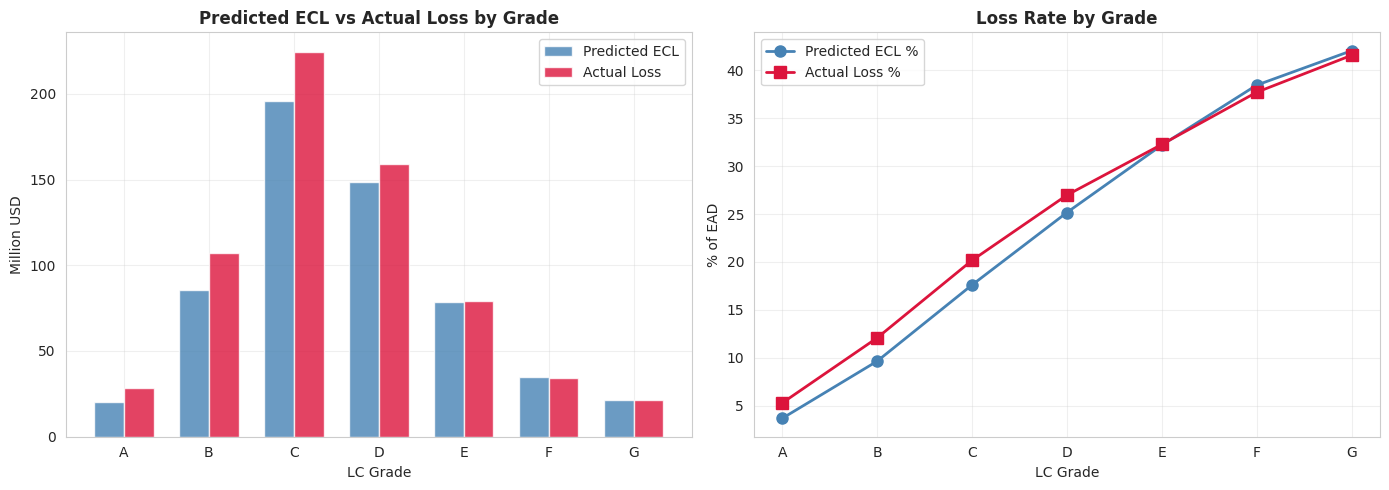

In [14]:
# Aggregate by grade
ecl_summary = portfolio.groupby('grade').agg(
    n_loans=('ead', 'count'),
    total_ead=('ead', 'sum'),
    avg_pd=('pd', 'mean'),
    avg_lgd=('lgd', 'mean'),
    total_predicted_ecl=('ecl', 'sum'),
    total_actual_loss=('actual_loss', 'sum'),
    default_rate=('actual_default', 'mean'),
).reset_index()

ecl_summary['grade_label'] = ecl_summary['grade'].map(grade_letter_map)
ecl_summary['ecl_pct'] = ecl_summary['total_predicted_ecl'] / ecl_summary['total_ead'] * 100
ecl_summary['actual_pct'] = ecl_summary['total_actual_loss'] / ecl_summary['total_ead'] * 100

# Format for display
display_cols = ['grade_label', 'n_loans', 'avg_pd', 'avg_lgd', 'ecl_pct', 'actual_pct']
display_summary = ecl_summary[display_cols].copy()
display_summary.columns = ['Grade', 'N Loans', 'Avg PD', 'Avg LGD', 'Predicted ECL %', 'Actual Loss %']

print("Portfolio ECL by Grade:\n")
print(display_summary.round(4).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted ECL$ vs Actual losses$ by grade
ax = axes[0]
x = range(len(ecl_summary))
width = 0.35
ax.bar([i - width/2 for i in x], ecl_summary['total_predicted_ecl'] / 1e6,
       width, label='Predicted ECL', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], ecl_summary['total_actual_loss'] / 1e6,
       width, label='Actual Loss', color='crimson', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ecl_summary['grade_label'])
ax.set_xlabel('LC Grade')
ax.set_ylabel('Million USD')
ax.set_title('Predicted ECL vs Actual Loss by Grade', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Loss % rates
ax = axes[1]
ax.plot(x, ecl_summary['ecl_pct'], 'o-', label='Predicted ECL %', color='steelblue', linewidth=2, markersize=8)
ax.plot(x, ecl_summary['actual_pct'], 's-', label='Actual Loss %', color='crimson', linewidth=2, markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(ecl_summary['grade_label'])
ax.set_xlabel('LC Grade')
ax.set_ylabel('% of EAD')
ax.set_title('Loss Rate by Grade', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Add to portfolio DataFrame
portfolio['int_rate'] = X_test_pd['int_rate'].values
portfolio['term'] = X_test_pd['term'].values
portfolio['installment'] = X_test_pd['installment'].values

# Revenue if loan is fully paid (total interest earned)
portfolio['revenue_if_paid'] = portfolio['installment'] * portfolio['term'] - portfolio['ead']

# Loss if loan defaults
portfolio['loss_if_default'] = portfolio['lgd'] * portfolio['ead']

# Expected profit per loan = P(non-default) × revenue - P(default) × loss
portfolio['expected_profit'] = (
    (1 - portfolio['pd']) * portfolio['revenue_if_paid']
    - portfolio['pd'] * portfolio['loss_if_default']
)

# Actual profit/loss (if we had approved everyone and used actual outcomes)
portfolio['actual_profit'] = np.where(
    portfolio['actual_default'] == 0,
    portfolio['revenue_if_paid'],
    -portfolio['loss_if_default']
)

print("Per-loan economics summary:\n")
print(portfolio[['pd', 'lgd', 'ead', 'revenue_if_paid',
                 'loss_if_default', 'expected_profit', 'actual_profit']].describe().round(2))

print(f"\nPortfolio totals (if approving everyone):")
print(f"  Total revenue if all pay:   ${portfolio['revenue_if_paid'].sum() / 1e6:>10,.2f}M")
print(f"  Total actual profit:        ${portfolio['actual_profit'].sum() / 1e6:>10,.2f}M")
print(f"  Expected profit (model):    ${portfolio['expected_profit'].sum() / 1e6:>10,.2f}M")

Per-loan economics summary:

               pd         lgd         ead  revenue_if_paid  loss_if_default  \
count 240864.0000 240864.0000 240864.0000      240864.0000      240864.0000   
mean       0.2400      0.6100  14604.7100        4682.8000        8963.6500   
std        0.1500      0.0500   9678.9600        5120.3700        6085.0600   
min        0.0100      0.5400   1000.0000      -18724.4000         537.9900   
25%        0.1200      0.5700   7000.0000        1276.2800        4154.7900   
50%        0.2100      0.6200  12000.0000        2679.0000        7449.1100   
75%        0.3300      0.6200  20000.0000        6327.7000       12467.1300   
max        0.8400      0.7700  40000.0000       39114.2000       30822.4000   

       expected_profit  actual_profit  
count      240864.0000    240864.0000  
mean          691.6600       289.5600  
std          1948.3700      8150.8000  
min        -19754.9900    -30822.4000  
25%            10.0900     -2151.9700  
50%           442.2

In [16]:
# Simulate cutoffs from 0.05 to 0.95 in steps of 0.01
cutoffs = np.arange(0.05, 0.95, 0.01)

results = []
for cutoff in cutoffs:
    # Approve loans with predicted PD < cutoff
    approved = portfolio['pd'] < cutoff
    n_approved = approved.sum()

    if n_approved == 0:
        continue

    approved_loans = portfolio[approved]

    # Calculate metrics
    approval_rate = n_approved / len(portfolio)
    bad_rate_approved = approved_loans['actual_default'].mean()
    total_ead = approved_loans['ead'].sum()
    total_revenue = approved_loans[approved_loans['actual_default'] == 0]['revenue_if_paid'].sum()
    total_loss = approved_loans[approved_loans['actual_default'] == 1]['loss_if_default'].sum()
    net_profit = total_revenue - total_loss
    roi = net_profit / total_ead if total_ead > 0 else 0

    results.append({
        'cutoff': cutoff,
        'approval_rate': approval_rate,
        'n_approved': n_approved,
        'bad_rate_approved': bad_rate_approved,
        'total_ead': total_ead,
        'total_revenue': total_revenue,
        'total_loss': total_loss,
        'net_profit': net_profit,
        'roi': roi,
    })

results_df = pd.DataFrame(results)

# Find optimal cutoff (maximize net profit)
optimal_idx = results_df['net_profit'].idxmax()
optimal_cutoff = results_df.loc[optimal_idx]

print(f"Cutoff Simulation Results — {len(results_df)} scenarios tested\n")
print(f"Optimal cutoff: {optimal_cutoff['cutoff']:.2f}")
print(f"  Approval rate:    {optimal_cutoff['approval_rate']*100:.1f}%")
print(f"  Approved loans:   {optimal_cutoff['n_approved']:,}")
print(f"  Bad rate (approved): {optimal_cutoff['bad_rate_approved']*100:.2f}%")
print(f"  Total revenue:    ${optimal_cutoff['total_revenue'] / 1e6:>10,.2f}M")
print(f"  Total loss:       ${optimal_cutoff['total_loss'] / 1e6:>10,.2f}M")
print(f"  Net profit:       ${optimal_cutoff['net_profit'] / 1e6:>10,.2f}M")
print(f"  ROI on EAD:       {optimal_cutoff['roi']*100:.2f}%")

# Compare with "approve all" baseline
approve_all = portfolio['actual_profit'].sum()
print(f"\nBaseline (approve all 240K loans):")
print(f"  Net profit: ${approve_all / 1e6:>10,.2f}M")

print(f"\nProfit improvement from optimal cutoff: "
      f"${(optimal_cutoff['net_profit'] - approve_all) / 1e6:+,.2f}M "
      f"({(optimal_cutoff['net_profit'] / approve_all - 1) * 100:+.1f}%)")

Cutoff Simulation Results — 90 scenarios tested

Optimal cutoff: 0.34
  Approval rate:    76.2%
  Approved loans:   183,523.0
  Bad rate (approved): 19.46%
  Total revenue:    $    460.40M
  Total loss:       $    317.46M
  Net profit:       $    142.94M
  ROI on EAD:       5.72%

Baseline (approve all 240K loans):
  Net profit: $     69.74M

Profit improvement from optimal cutoff: $+73.20M (+105.0%)


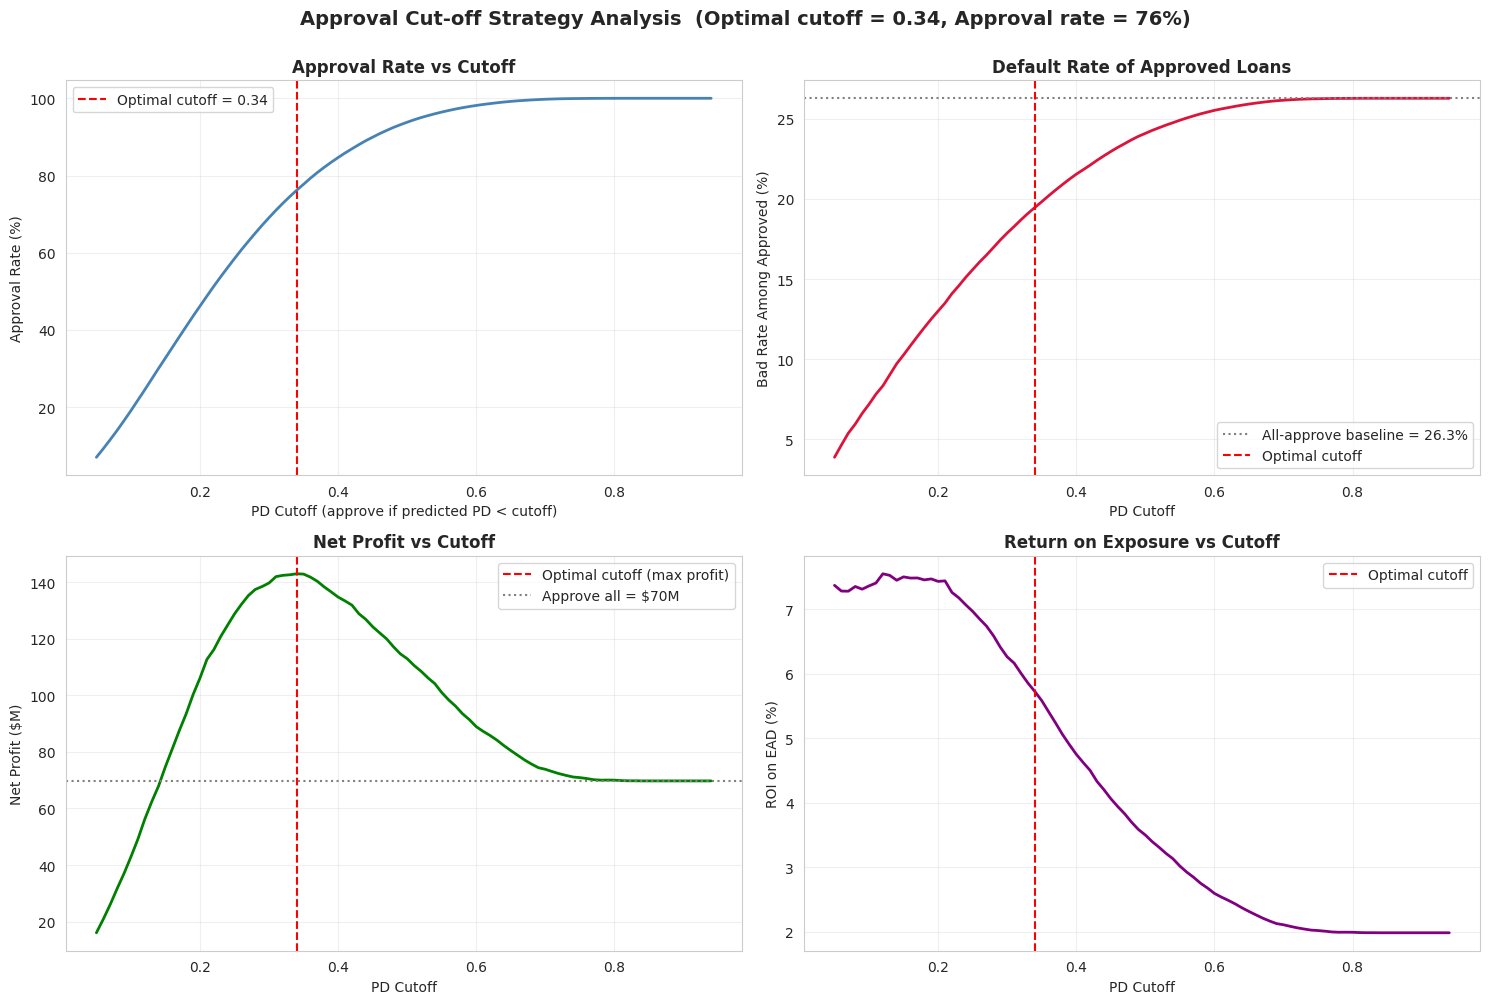

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Approval rate vs cutoff
ax = axes[0, 0]
ax.plot(results_df['cutoff'], results_df['approval_rate'] * 100,
        linewidth=2, color='steelblue')
ax.axvline(optimal_cutoff['cutoff'], color='red', linestyle='--',
           label=f"Optimal cutoff = {optimal_cutoff['cutoff']:.2f}")
ax.set_xlabel('PD Cutoff (approve if predicted PD < cutoff)')
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Approval Rate vs Cutoff', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Bad rate (among approved) vs cutoff
ax = axes[0, 1]
ax.plot(results_df['cutoff'], results_df['bad_rate_approved'] * 100,
        linewidth=2, color='crimson')
ax.axhline(portfolio['actual_default'].mean() * 100, color='gray', linestyle=':',
           label=f"All-approve baseline = {portfolio['actual_default'].mean()*100:.1f}%")
ax.axvline(optimal_cutoff['cutoff'], color='red', linestyle='--',
           label=f"Optimal cutoff")
ax.set_xlabel('PD Cutoff')
ax.set_ylabel('Bad Rate Among Approved (%)')
ax.set_title('Default Rate of Approved Loans', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Net profit vs cutoff
ax = axes[1, 0]
ax.plot(results_df['cutoff'], results_df['net_profit'] / 1e6,
        linewidth=2, color='green')
ax.axvline(optimal_cutoff['cutoff'], color='red', linestyle='--',
           label=f"Optimal cutoff (max profit)")
ax.axhline(approve_all / 1e6, color='gray', linestyle=':',
           label=f"Approve all = ${approve_all/1e6:.0f}M")
ax.set_xlabel('PD Cutoff')
ax.set_ylabel('Net Profit ($M)')
ax.set_title('Net Profit vs Cutoff', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: ROI vs cutoff
ax = axes[1, 1]
ax.plot(results_df['cutoff'], results_df['roi'] * 100,
        linewidth=2, color='purple')
ax.axvline(optimal_cutoff['cutoff'], color='red', linestyle='--',
           label=f"Optimal cutoff")
ax.set_xlabel('PD Cutoff')
ax.set_ylabel('ROI on EAD (%)')
ax.set_title('Return on Exposure vs Cutoff', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle(f'Approval Cut-off Strategy Analysis  '
             f'(Optimal cutoff = {optimal_cutoff["cutoff"]:.2f}, '
             f'Approval rate = {optimal_cutoff["approval_rate"]*100:.0f}%)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [18]:
# Define interesting scenarios
scenarios = {
    'Very Conservative (cutoff=0.15)': 0.15,
    'Conservative (cutoff=0.25)':       0.25,
    'Optimal':                          optimal_cutoff['cutoff'],
    'Lenient (cutoff=0.50)':            0.50,
    'Approve Almost All (cutoff=0.80)': 0.80,
}

scenario_results = []
for name, cutoff in scenarios.items():
    approved = portfolio['pd'] < cutoff
    approved_loans = portfolio[approved]
    n_approved = approved.sum()

    if n_approved == 0:
        continue

    scenario_results.append({
        'Scenario': name,
        'Cutoff': cutoff,
        'Approval %': f"{approved.mean()*100:.1f}%",
        'N Approved': f"{n_approved:,}",
        'Bad Rate': f"{approved_loans['actual_default'].mean()*100:.2f}%",
        'Revenue ($M)': f"{approved_loans[approved_loans['actual_default']==0]['revenue_if_paid'].sum()/1e6:.1f}",
        'Loss ($M)': f"{approved_loans[approved_loans['actual_default']==1]['loss_if_default'].sum()/1e6:.1f}",
        'Net Profit ($M)': f"{(approved_loans[approved_loans['actual_default']==0]['revenue_if_paid'].sum() - approved_loans[approved_loans['actual_default']==1]['loss_if_default'].sum())/1e6:.1f}",
    })

scenarios_df = pd.DataFrame(scenario_results)
print("Cut-off Strategy Scenarios:\n")
print(scenarios_df.to_string(index=False))

Cut-off Strategy Scenarios:

                        Scenario  Cutoff Approval % N Approved Bad Rate Revenue ($M) Loss ($M) Net Profit ($M)
 Very Conservative (cutoff=0.15)  0.1500      32.8%     78,912   10.27%        138.0      63.1            74.8
      Conservative (cutoff=0.25)  0.2500      58.5%    140,902   15.59%        311.3     182.5           128.8
                         Optimal  0.3400      76.2%    183,523   19.46%        460.4     317.5           142.9
           Lenient (cutoff=0.50)  0.5000      93.8%    225,960   24.08%        645.7     532.8           112.9
Approve Almost All (cutoff=0.80)  0.8000     100.0%    240,848   26.26%        723.4     653.4            70.0


In [19]:
# Save LGD model + portfolio results
joblib.dump(lgd_model, f'{MODELS_DIR}/lgd_model.pkl')
joblib.dump(lgd_by_grade, f'{MODELS_DIR}/lgd_by_grade.pkl')

# Save portfolio results
portfolio.to_parquet(f'{DRIVE_PATH}/portfolio_ecl.parquet')
results_df.to_parquet(f'{DRIVE_PATH}/cutoff_simulation.parquet')
scenarios_df.to_csv(f'{DRIVE_PATH}/cutoff_scenarios.csv', index=False)

# Update metadata
import json
with open(f'{MODELS_DIR}/model_metadata.json', 'r') as f:
    metadata = json.load(f)

metadata['lgd_model'] = {
    'algorithm': 'LGBMRegressor',
    'objective': 'regression_l1 (MAE)',
    'mae': 0.1469,
    'rmse': 0.1902,
    'r2': 0.2259,
}

metadata['portfolio_summary'] = {
    'total_ead': float(portfolio['ead'].sum()),
    'predicted_ecl': float(portfolio['ecl'].sum()),
    'actual_loss': float(portfolio['actual_loss'].sum()),
    'optimal_cutoff': float(optimal_cutoff['cutoff']),
    'optimal_approval_rate': float(optimal_cutoff['approval_rate']),
    'optimal_net_profit': float(optimal_cutoff['net_profit']),
    'baseline_net_profit': float(approve_all),
    'profit_improvement_pct': float((optimal_cutoff['net_profit']/approve_all - 1) * 100),
}

with open(f'{MODELS_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ All artifacts saved\n")
print("Files in models/:")
for f in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(f'{MODELS_DIR}/{f}') / 1024
    print(f"  {f:<25} {size:>8.1f} KB")

✓ All artifacts saved

Files in models/:
  feature_names.pkl              2.4 KB
  lgb_model.pkl               3519.8 KB
  lgd_by_grade.pkl               0.1 KB
  lgd_model.pkl               2950.4 KB
  lr_model.pkl                   1.9 KB
  model_metadata.json            1.4 KB
  scaler.pkl                     6.4 KB
